In [31]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching

GKP logical qubits are continous variables

$$ \ket{0}_L = \sum^{\infty}_{k = 0} \ket{2k\pi} \qquad \ket{1}_L = \sum^{\infty}_{k = 0} \ket{(2k+1)\pi}$$

we can simulate these by picking a large value N instead of infinity, and parameters to squeeze and build the peaks of these states.

These quits manifest as lattice sites in phase space, that can be displayed as a porbability density function called the Wiegner (check spelling) function. This gives the probability of the qubit exisiting in given momentum (or momenta -check) and position. 

All qubits experience errors on their information. In these gkp qubits, the errors can appear in both momentum and position, cannot correct for both uncertinty princile

Squeeze the qubit so most of it lies iin just one of the axis in phase space - then most errors just in one side

Also qutip uses 

$$ \alpha = \frac{q + ip}{\sqrt{2}} $$

so i need to account for that bc i forgot to when i origiannly made the gkp wigner function plots

In [25]:
#parameters
N = 200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
noise = 0.1 # for displacement noise
n_trials = 500 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

def pos_to_alpha(q, p=0): #will correct first for only q  noise 
    return (q + 1j* p) /sqrt_2 #takes values into qutip alpha ranges

def GKP_built(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    # gkp logical 0
    # = sum k | q = 2k sqrt pi>
    gkp = 0 * peak_state #sets it to zero state rather than 1
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        alpha = pos_to_alpha(2 * k * sqrt_pi)
        D = displace(N, alpha)
        gkp += weight * D * peak_state

    return gkp.unit()

state = GKP_built(N, delta, epsilon, n)

KeyboardInterrupt: 

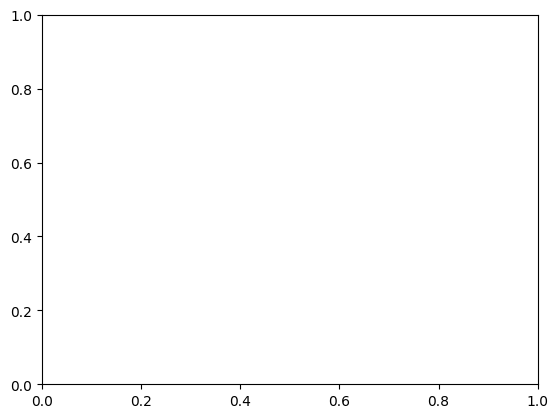

In [26]:
plot_wigner(state)

Stabilisers check if an error has occured. Here the stabilisers are also continuous variables like the qubits are. They are

$$ S_q = e^{i2\sqrt{x}\hat{q}} \quad S_p = e^{-i2\sqrt{x}\hat{p}} $$

GKP peaks repeat every $ 2\sqrt{pi} $ and the stabilisers encode that.

The displacement of a qkp qubit is done with the operator $ D(\alpha) $ that can shift position and momentum.

$$ D(\alpha) = e^{\alpha a^{+} - \alpha^* a} $$

where p and q are made up of the creation and anhilation ops a and a adgger.

$S_q$ detectd dp changes and $S_p$ for dq values.

In [ ]:
Sq = displace(N, pos_to_alpha(2*sqrt_pi, 0))
Sp = displace(N, pos_to_alpha(0, 2*sqrt_pi))

Testing the displacements effect on the state - it didnt work last attempt so have had to re do and am doing more teste along the way

In [ ]:
#Test for one displacement using the aplha para,eter change thing
dq = 0.2

D = displace(N, pos_to_alpha(dq))
psi = (D*state).unit()

sq = expect(Sq, psi)
sp = expect(Sp, psi)

print("Sq =", sq, "phase =", np.angle(sq))
print("Sp =", sp, "phase =", np.angle(sp))

Sq = (0.881911457015154+0j) phase = 0.0
Sp = (0.5720874545007288+0.4907133605818868j) phase = 0.7089815513351168


Shows phase on Sp so use this to detect dq errors.

Recovery test below: after stab measurement can we see how much the state was displaced by

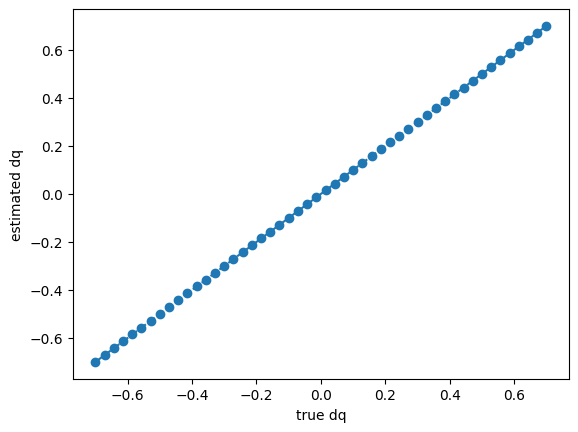

In [ ]:
dq_vals = np.linspace(-0.7,0.7,50)

recovered = []

for dq in dq_vals:
    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)

    dq_est = np.angle(s)/(2*sqrt_pi)

    recovered.append(dq_est)

plt.plot(dq_vals, dq_vals, '--')
plt.scatter(dq_vals, recovered)
plt.xlabel("true dq")
plt.ylabel("estimated dq")
plt.show()

Its linear which is goood and hopefully means the conversion of dq to the stabiliser if correct yay


Larger range test to see what happens outide the descision boundary of $\frac{\sqrt{\pi}}{2}$

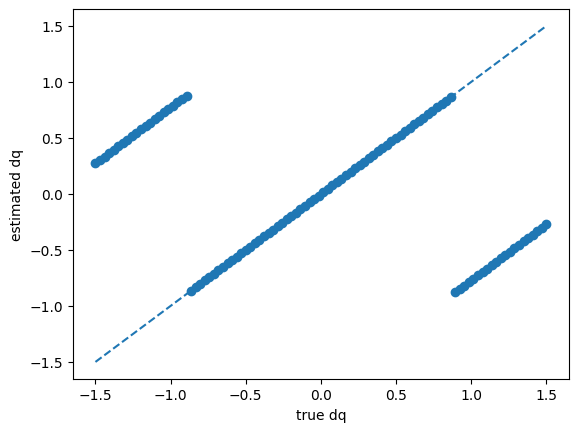

In [ ]:
dq_vals = np.linspace(-1.5,1.5,100)

recovered = []

for dq in dq_vals:
    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)

    dq_est = np.angle(s)/(2*sqrt_pi)

    recovered.append(dq_est)

plt.plot(dq_vals, dq_vals, '--')
plt.scatter(dq_vals, recovered)
plt.xlabel("true dq")
plt.ylabel("estimated dq")
plt.show()

Addition of Gaussian Noise

starting with just dq noise

Gaussian noise, with a noise parameter defined above

In [ ]:
#noise generation
dq = np.random.normal(0, noise)
#apply noise to a gkp state
psi = (displace(N, pos_to_alpha(dq))*state).unit() #normalise too
#compute expectation value between state and stabiliser
s = expect(Sp, psi)
dq_est = np.angle(s)/(2*sqrt_pi)
#correct - risidual - error yes or no 
correction = -dq_est
residual = dq + correction
print('for random risidual:', residual)

dq = 1.0
psi = (displace(N, pos_to_alpha(dq))*state).unit() #normalise too
#compute expectation value between state and stabiliser
s = expect(Sp, psi)
dq_est = np.angle(s)/(2*sqrt_pi)
#correct - risidual - error yes or no 
correction = -dq_est
residual = dq + correction
print('for a dq that crosses boundary:',residual)

for random risidual: -1.1017702028492948e-09
for a dq that crosses boundary: 1.7724538263796519


The random seems to be working, and when i force a large shift it produced a value close to $\sqrt{\pi}$ which is good for a dq of 1.

can apply errors to many qubits now and get a histogram of the gaussian noise

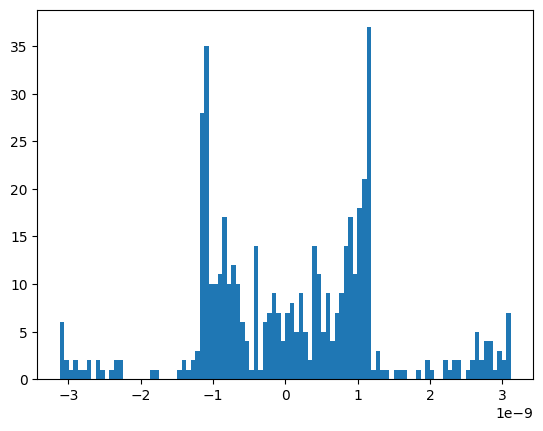

In [ ]:
residuals = []

for _ in range(500):
    dq = np.random.normal(0, noise)

    psi = (displace(N, pos_to_alpha(dq))*state).unit()

    s = expect(Sp, psi)
    dq_est = np.angle(s)/(2*sqrt_pi)

    residuals.append(dq - dq_est)

plt.hist(residuals, bins=100)
plt.show()

In [ ]:
def wrap_to_lattice(x):
    return np.round(x / sqrt_pi) * sqrt_pi

dq_est_wrapped = wrap_to_lattice(dq_est)

#error = abs(dq - dq_est_wrapped) > sqrt_pi/2

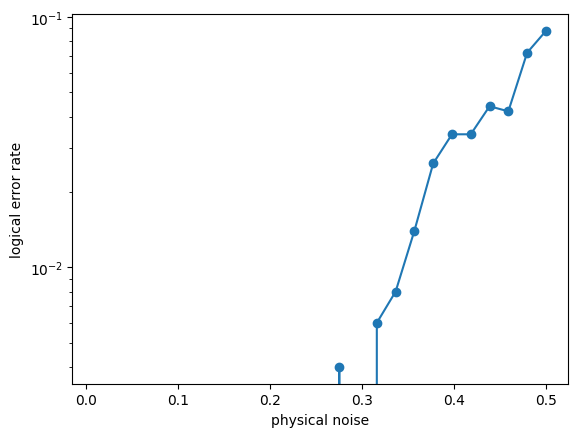

In [49]:
sigma_list = np.linspace(0.01, 0.5, 25)
logical_rates = []

for sigma in sigma_list:
    dq = np.random.normal(0, sigma, n_trials)
    
    # syndrome measurement
    sq = ((dq + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
    
    # decoder corrects by -sq
    correction = -sq
    residual = dq + correction
    
    # logical error if residual crosses boundary
    errors = np.mean(np.abs(residual) > sqrt_pi/2)
    logical_rates.append(errors)

plt.plot(sigma_list, logical_rates, marker='o')
plt.xlabel("physical noise")
plt.ylabel("logical error rate")
plt.yscale("log")
plt.show()

not sure this is good icl but do not have time to fix again before i fly back 

In [34]:
def repetition_code(n):
    H = np.zeros((n-1, n), dtype=int)
    for i in range(n-1):
        H[i, i]   = 1
        H[i, i+1] = 1
    return H

H1 = repetition_code(3)
H2 = repetition_code(3)
H2T = H2.T
r1, n1 = H1.shape
r2, n2 = H2.shape
I2T = np.eye(n2, dtype=int) #identity matrix in the shape of the rows of H1 or H2
I1 = np.eye(r1, dtype=int) #identity matrix in the shape of the columns of H1 or H2

def hypergraphHxHz(H1, H2T, I1, I2T):
    """
    Args:
        H1 (array?): 3 bit code thing
        H2 (_type_): same as above
        I1 (_type_): identity matrix 
        I2T (_type_): identity matrix

    Returns: 
        Hx, Hz for hypergraph codes
    """
    Hxr = np.kron(H1, I2T)
    Hxl= np.kron(I1, H2T)
    Hx = np.hstack([Hxr, Hxl])

    Hzr = np.kron(I2T, H1)
    Hzl = np.kron(H2T, I1)
    Hz = np.hstack([Hzr, Hzl])
    return Hx, Hz

Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T) #this gives a list of which stabilisers (rows) touch which qubits (columns)
#print(I2T)
print(Hx)
print(Hz)

def get_logical_z(d):
    r = d - 1  # rows of H
    n = d      # cols of H
    n_top = n * n        # = d²
    n_bot = r * r        # = (d-1)²
    n_qubits = n_top + n_bot

    logical = np.zeros(n_qubits, dtype=np.uint8)
    for i in range(n):
        logical[i * n] = 1
    return logical

logical_z = get_logical_z(3)

[[1 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 1]]
[[1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 1]]


pymatching small test first

In [32]:
matching = pymatching.Matching.from_check_matrix(Hz)

In [35]:
n_qubits = Hz.shape[1]

e = np.zeros(n_qubits, dtype=np.uint8)
e[0] = 1

syndrome = (Hz @ e) % 2
correction = matching.decode(syndrome)
print(correction)

residual = (e + correction) % 2
print(residual)

logical_fail = (residual @ logical_z) % 2
print(logical_fail)

[1 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
0


test monte calro

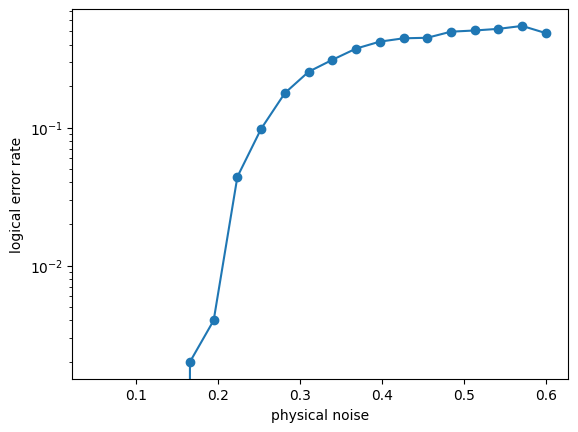

In [56]:
p = 0.05
sigma_vals = np.linspace(0.05, 0.6, 20)

logical_rate = []
sq_vals = []

for sigma in sigma_vals:
    errors = 0

    for _ in range(n_trials):
        e = np.zeros(Hz.shape[1], dtype=np.uint8)
        sq_vals = np.zeros(Hz.shape[1])

        for q in range(Hz.shape[1]):
            dq = np.random.normal(0, sigma)
            sq = ((dq + sqrt_pi/2) % sqrt_pi) - sqrt_pi/2
            sq_vals[q] = sq

        e = (np.abs(sq_vals) > sqrt_pi/4).astype(np.uint8)

        syndrome = (Hz @ e) % 2
        correction = matching.decode(syndrome)
        residual = (e + correction) % 2

        if (residual @ logical_z) % 2:
            errors += 1

    logical_rate.append(errors / n_trials)

plt.semilogy(sigma_vals, logical_rate, marker='o') # does yscale log in the plot thats cool
plt.xlabel("physical noise")
plt.ylabel("logical error rate")
plt.show()